# Übung 4

**Gruppenname:**

*WMJ*

Gehen Sie wie folgt vor:

1. Bitte benennen Sie jetzt dieses Jupyter Notebook um (z.B. über `File -> Rename`):

   Namensschema: `Gruppenname-X`. Ersetzen Sie "X" mit der oben angegebenen Nummer der Übung.

   - Beispiel 1: Team REZA bearbeitet Übung 2. Das Notebook heißt: REZA-2.
   - Beispiel 2: Sie sind keinem Team zugeordnet (nicht empfehlenswert) und bearbeiten Übung 2: Ihr Notebook heißt: Nachname-2.


2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Vergessen Sie dabei nicht, das Jupyter Notebook regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

### In dieser Übung ...

werden Sie verschiedene Datensätze explorieren und dabei Ihre EDA-Fertigkeiten trainieren.

### 4.1 Visualisierung Teil 1 (Lebenserwartung)

In dieser Übung geht es darum, dass Sie Ihre Pandas- und Visualisierungs-Fähigkeiten weiter verfeinern. Wir werden die Entwicklung der Lebenserwartung der Weltbevölkerung in den letzten 200 Jahren untersuchen.

**Ihre Daten**

Die Daten stammen aus unterschiedlichen Datenquellen (unter anderem den United Nations, dem Institute for Health Metrics and Evaluation, der Human Mortality Database des Max Plank Instituts für demografische Forschung und der University of California Berkeley), die von der Gapminder Stiftung zusammengefasst wurden. Sie finden die Daten hier:

* Sie finden die Daten, die Sie für diese Übung benötigen, [hier](https://data.bialonski.de/ds/life_expectancy_years.csv).

**Ihre Aufgaben**

(1) Welche Erwartungshaltung haben Sie - ohne dass Sie vorher recherchieren: Was war die durchschnittliche Lebenserwartung eines Menschen zu Beginn des 19. Jahrhunderts (also 18XX) und im Jahr 2018? (1-3 Sätze)

Wir würden vermuten, dass die durchschnittliche Lebenserwartung im Jahr `2018` bei ungefähr 80 liegt.
Zu Beginn des 19. Jahrhunderts liegt dieser Wert vermutlich deutlich tiefer, vielleicht 50-60?

(2) Importieren und untersuchen Sie den hinterlegten Datensatz: Für welche Zeitspanne sind Daten hinterlegt?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

life_expectancy_years = pd.read_csv("./data/life_expectancy_years.csv", index_col="country")
life_expectancy_years.rename(columns=lambda year: int(year), inplace=True)
columns = life_expectancy_years.columns
print(f"{columns.min()=}, {columns.max()=}, zeitspanne={columns.max()-columns.min()}")

columns.min()=1800, columns.max()=2018, zeitspanne=218


Der kleinste Datenwert liegt bei 1800;
Der größte Datenwert liegt bei 2018.

Somit ist unsere Datenspanne bei 218 Jahren.

(3) Erstellen Sie eine Visualisierung der weltweiten Lebenserwartung (y-Achse) über die Jahre (x-Achse) hinweg. Halten Sie sich an die Regeln guter Visualisierung. Achten Sie auf Achsenbeschriftungen.

* Hinweis: Zur Bearbeitung dieser Aufgabe werden Sie im Netz recherchieren müssen.

[]

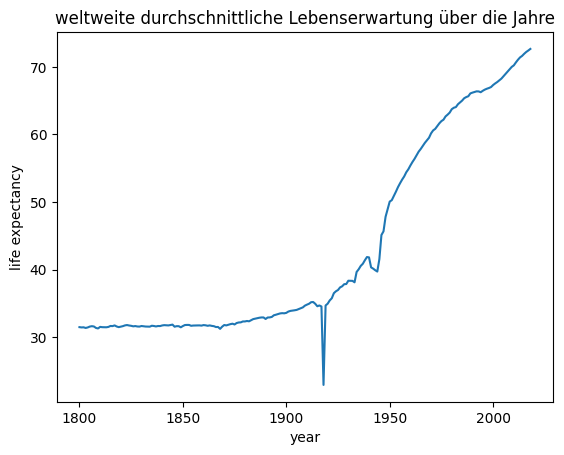

In [2]:
life_expectancy_years_mean = life_expectancy_years.mean().transpose()
life_expectancy_years_mean.plot(title="weltweite durchschnittliche Lebenserwartung über die Jahre")

plt.xlabel("year")
plt.ylabel("life expectancy")
plt.plot()

(4) Vergleichen Sie Ihre Abbildung mit Ihrer Erwartungshaltung aus Schritt (1). Wurden Sie überrascht? Falls ja, inwiefern? (1-3 Sätze)

Die aktuelle Lebenserwartung konnten wir noch relativ genau abschätzen.

Bei der Lebenserwartung vor 200 Jahren waren wir zu optimistisch.

(5) Führen Sie eine kurze Recherche durch: Welche Ereignisse könnten die Einbrüche in der weltweiten Lebenserwartung, die Sie zu bestimmten Zeiten beobachten, erklären?

In [3]:
life_expectancy_years_mean[life_expectancy_years_mean <= life_expectancy_years_mean.sort_values().to_list()[5]]

1803    31.383152
1804    31.459239
1808    31.383152
1809    31.310326
1868    31.249511
1918    22.956250
dtype: float64

https://de.wikipedia.org/wiki/1918

Vermutlich war der 1. Weltkriegs maßgeblich relevant für die Einbrüche der Lebenserwartung

(6) \[Optional\]: Vergleichen Sie die weltweite Lebenserwartung mit der von Deutschland: Erstellen Sie eine Visualisierung, die beide Graphen zeigt, und interpretieren Sie diese. (1-3 Sätze).

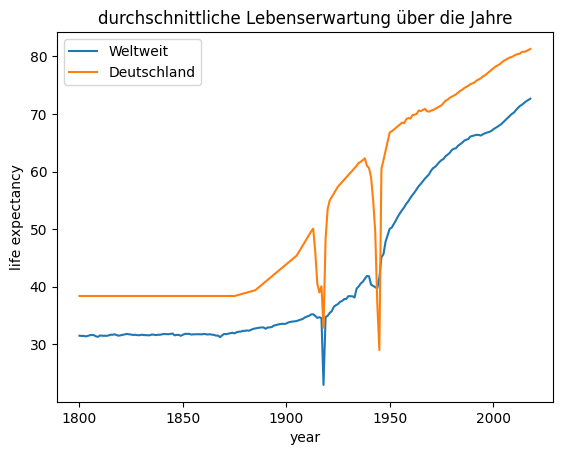

In [4]:
life_expectancy_years_mean.plot(label="Weltweit", title="durchschnittliche Lebenserwartung über die Jahre")
life_expectancy_years.loc["Germany"].plot(label="Deutschland")

plt.xlabel("year")
plt.ylabel("life expectancy")
plt.legend()
plt.show()

### 4.2 Visualisierung Teil 2 (Geburtenraten)

Dies ist eine Fortsetzung von vorherigen Übungsaufgaben. Wir kommen noch einmal auf Daten der Gapminder Stiftung zurück, um Geburtenraten weltweit zu untersuchen.

**Ihre Daten**

* Sie finden die Daten, die Sie für diese Übung benötigen, [hier](https://data.bialonski.de/ds/children_per_woman_total_fertility.csv).

**Randbemerkung**

Im Rahmen dieser Aufgabe wollen wir unter dem Begriff "Geburtenrate" die Gesamtfertilitätsrate (*total fertility rate*) verstehen, wie Sie sie direkt im Datensatz angegeben finden. Dies ist die durchschnittliche Anzahl von Kindern, die eine Frau im Laufe ihres Lebens bekommt. Die Forschung [unterscheidet](https://web.archive.org/web/20220502150023/https://www.gbe-bund.de/gbe/abrechnung.prc_abr_test_logon?p_uid=gast&p_aid=0&p_knoten=FID&p_sprache=D&p_suchstring=12693) allerdings zwischen verschiedenen Fertilitätsindikatoren (z.B. zwischen sogenannten Geburtenziffern, Fertilitätsraten und Reproduktionsraten). Falls Sie also einmal mit einem Bevölkerungswissenschaftler sprechen sollten: Sie untersuchen hier im Rahmen dieser Aufgabe die Gesamtfertilitätsrate.

**Ihre Aufgaben**

(1) Importieren Sie den oben aufgeführten Datensatz.

In [5]:
children_per_woman_total_fertility = pd.read_csv("data/children_per_woman_total_fertility.csv", index_col="country")
children_per_woman_total_fertility.rename(columns=lambda year: int(year), inplace=True)

(2) Visualisieren Sie die weltweite Geburtenrate (y-Achse) als Funktion der Zeit (Jahre, x-Achse). Achten Sie auf die Regeln guter Visualisierung, wie Sie sie in der Vorlesung kennengelernt haben. Beschriften Sie alle Achsen.

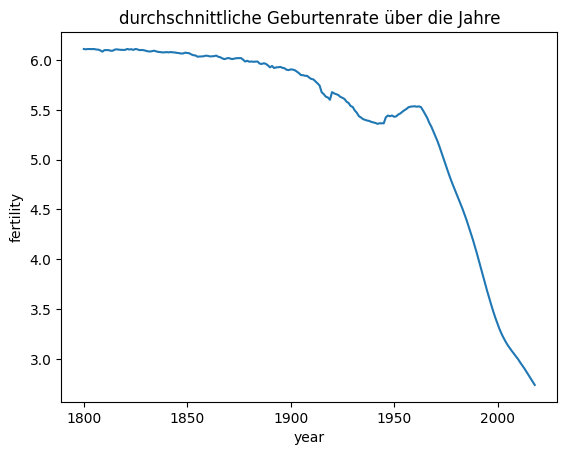

In [6]:
children_per_woman_total_fertility_mean = children_per_woman_total_fertility.mean().transpose()
children_per_woman_total_fertility_mean.plot(title="durchschnittliche Geburtenrate über die Jahre")

plt.xlabel("year")
plt.ylabel("fertility")
plt.show()

(3) Ab wann geht die Geburtenrate weltweit besonders stark zurück? (ungefähre Jahreszahl). Welche Hypothesen haben Sie, warum dieser Rückgang zu beobachten ist?

Die Geburtenrate geht weltweit besonders stark 1960-heute zurück

(4) Ermitteln Sie für jedes Jahr das Land, in dem die Geburtenrate am meisten zurückging. (Ein *Pandas Series* Objekt).

 * Zur Bearbeitung dieser Aufgabe werden Sie etwas nachdenken müssen. Wenn Sie partout nicht weiterkommen, lesen Sie diesen ROT13-kodierten Hinweis: Qre Uvajrvf ynhgrg: uggcf://cnaqnf.clqngn.bet/cnaqnf-qbpf/fgnoyr/ersrerapr/ncv/cnaqnf.QngnSenzr.qvss.ugzy

In [7]:
children_per_woman_total_fertility_year = children_per_woman_total_fertility.transpose().diff()
children_per_woman_total_fertility_year_min = []
for index in children_per_woman_total_fertility_year.index[1:]:
    children_per_woman_total_fertility_year_min.append(children_per_woman_total_fertility_year.loc[index].index[children_per_woman_total_fertility_year.loc[index].argmin()])
children_per_woman_total_fertility_year_min = pd.Series(children_per_woman_total_fertility_year_min, index=children_per_woman_total_fertility_year.index[1:])
print(children_per_woman_total_fertility_year_min)

1801    United Kingdom
1802            Norway
1803           Finland
1804            Norway
1805    United Kingdom
             ...      
2014       Afghanistan
2015       Afghanistan
2016       Afghanistan
2017       Afghanistan
2018       Afghanistan
Length: 218, dtype: object


(5) Ermitteln Sie mit Ihrem Ergebnis aus Schritt (4) das Land, dessen Geburtenrate Ende der 80er und Anfang der 90er Jahre am stärksten zurückging. Um welches Land handelt es sich?

In [8]:
children_per_woman_total_fertility_year_min[[1989, 1990]]

1989    Iran
1990    Iran
dtype: object

Es handelt sich um `Iran`.

(6) Visualisieren Sie den Zeitverlauf der Geburtenraten für das Land, welches Sie in Schritt (5) identifiziert haben. Achten Sie auf die Regeln guter Visualisierung, die Sie in der Vorlesung kennengelernt haben. Was Sie beobachten, zählt zu den schnellsten Geburtenrückgängen der Weltgeschichte.

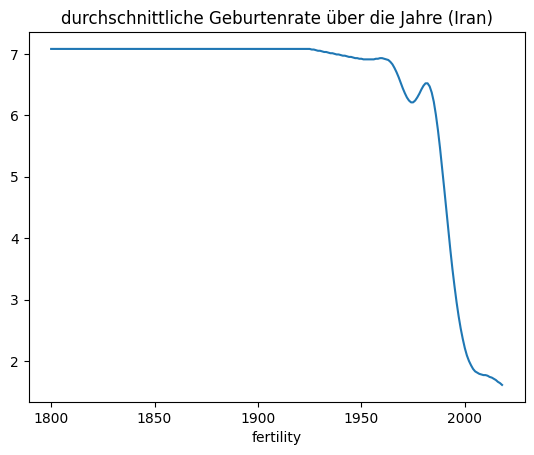

In [9]:
children_per_woman_total_fertility.loc["Iran"].plot(title="durchschnittliche Geburtenrate über die Jahre (Iran)")

plt.xlabel("year")
plt.xlabel("fertility")
plt.show()

(7) Fügen Sie der Abbildung aus Schritt (6) noch die Geburtenrate der USA als zusätzlichen Graphen hinzu. Beschreiben Sie grob den qualitativen Unterschied, den Sie feststellen (1-3 Sätze).

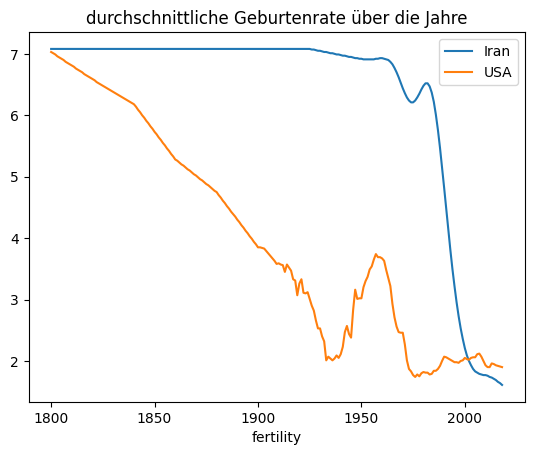

In [10]:
children_per_woman_total_fertility.loc["Iran"].plot(title="durchschnittliche Geburtenrate über die Jahre", label="Iran")
children_per_woman_total_fertility.loc["United States"].plot(label="USA")

plt.xlabel("year")
plt.xlabel("fertility")
plt.legend()
plt.show()

Zu Beginn und am Ende der Daten nähern sich die Daten aneinander an.

Jedoch fällt die Geburtenrate in den USA deutlich flacher und früher ab, als im Iran.

In den Daten der USA gibt es einen kleinen Anstieg der Geburtenrate, der jedoch global vernachlässigbar ist.

** Schlussbemerkung** Wenn Sie mit Ihrer Aufgabe bis hierhin gekommen sind, dann lesen Sie gerne die ROT-13 kodierte Schlussbemerkung. Qre Vena ireorffregr Raqr qrf 20. Wnueuhaqregf qvr zrqvmvavfpur Irefbethat haq qvr Ovyqhat qre Oüetre qrhgyvpu. Rvar boyvtngbevfpur Frkhnynhsxyäehat, rvasnpure Mhtnat mh Ireuüghatfzvggrya (hagre naqrerz mhe Cvyyr) fbjvr rvar vz Vena orsvaqyvpur Xbaqbzsnoevx (qvr va qra 90re Wnuera teößgr Xbaqbzsnoevx jrygjrvg) jreqra mh qra irefpuvrqrara Snxgbera trmäuyg, qvr qra Trohegraeüpxtnat rexyäera.

### 4.3 Multivariate explorative Analyse (Mietspiegel)

In vielen Städte und Gemeinden werden sogenannte Mietspiegel erstellt, die eine Marktübersicht zu Miethöhen bereitstellen. Diese werden gerne von Sachverständigen, Vermietern und Mietinteressenten zurate gezogen. In §558, Ab- satz (2) des bürgerlichen Gesetzbuchs ist die ortsübliche Vergleichsmiete definiert: „Die ortsübliche Vergleichsmiete wird gebildet aus den üblichen Entgelten, die in der Gemeinde oder einer vergleichbaren Gemeinde für Wohnraum vergleichbarer Art, Größe, Ausstattung, Beschaffenheit und Lage einschließlich der energetischen Ausstattung und Beschaffenheit in den letzten vier Jahren vereinbart oder, von Erhöhungen nach §560 abgesehen, geändert worden sind.“ Das bedeutet für die Nettomiete, dass ihr Durchschnittswert in Abhängigkeit von Merkmalen wie Art, Größe, Ausstattung, Beschaffenheit und Lage der Wohnung zu bestimmen bzw. zu schätzen ist.

Im Rahmen dieser Übung werden Sie einen Mietspiegel aus München untersuchen, einer Gegend, die bekannt für außerordentlich hohe Mieten ist.

**Ihre Daten**

* Sie finden die Daten, die Sie für diese Übung benötigen, [hier](https://data.bialonski.de/ds/mietspiegel2015.txt).

**Ihre Aufgaben**

(1) Importieren Sie die Daten.

In [11]:
mietspiegel2015 = pd.read_csv("./data/mietspiegel2015.txt", sep=" ")

(2) Erzeugen Sie ein Säulendiagramm, dass die Häufigkeiten der Zimmeranzahl (rooms) zeigt.

[]

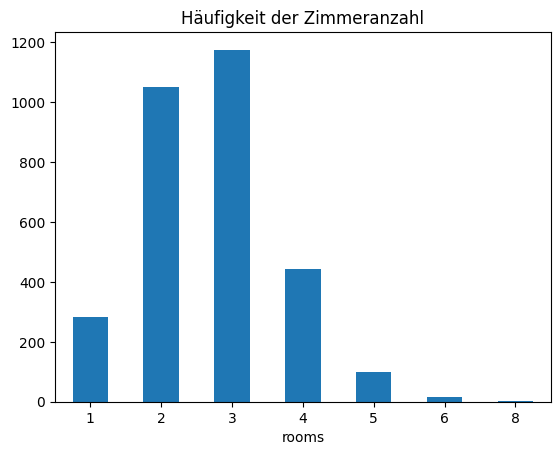

In [12]:
mietspiegel2015.groupby("rooms").size().plot(kind="bar", rot=0, title="Häufigkeit der Zimmeranzahl")
plt.plot()

(3) Erstellen Sie eine 5-Number-Summary (Fünf-Punkte–Zusammenfassung) für die Variable Baujahr (bj). 

In [13]:
mietspiegel2015["bj"].describe()[['min', '25%', '50%', '75%', 'max']]

min    1918.0
25%    1957.5
50%    1957.5
75%    1983.0
max    2012.5
Name: bj, dtype: float64

(4) Berechnen Sie die 5-Number-Summary für die Variablen Nettomiete (nm) und Nettomiete/Quadratmeter (nmqm), jeweils getrennt für Wohnungen, die vor bzw. nach dem Jahr 1958 gebaut wurden. Erstellen Sie ebenfalls die dazugehörigen Boxplots. Interpretieren Sie Ihre Ergebnisse. (1-3 Sätze)

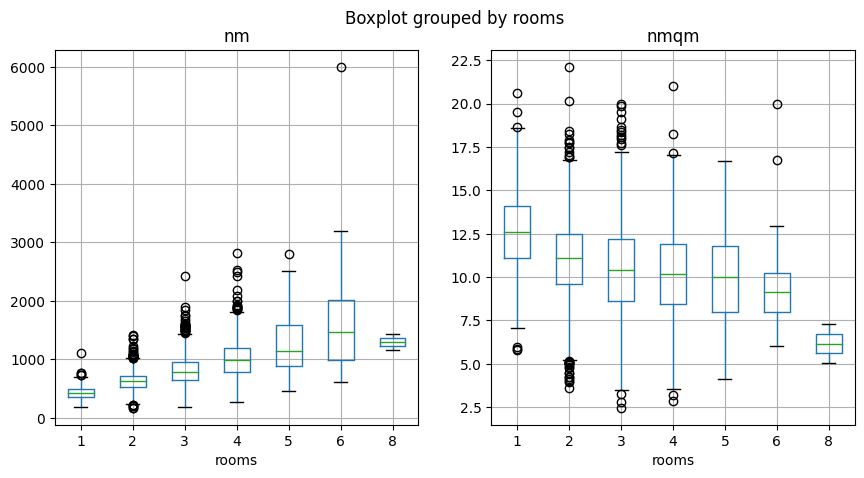

In [14]:
# print(mietspiegel2015.query("bj < 1958")[["nm", "nmqm"]].describe().loc[['min', '25%', '50%', '75%', 'max']])
# print(mietspiegel2015.query("bj >= 1958")[["nm", "nmqm"]].describe().loc[['min', '25%', '50%', '75%', 'max']])

mietspiegel2015["bj_ge_1958"] = mietspiegel2015["bj"] >= 1958
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
mietspiegel2015.boxplot(by="rooms", column="nm", ax=ax[0])
mietspiegel2015.boxplot(by="rooms", column="nmqm", ax=ax[1])
plt.show()

Der generelle Nettomietpreis (`nm`) und die Nettomiete pro Quadratmeter (`nmqm`) sind gestiegen.

Da die Nettomiete pro Quadratmeter ein höheres 0.25 Quantil hat, werden kleinere Wohnungen vermietet, die jedoch nicht preiswerter sind, als die größeren Wohnungen vor 1958.

(5) Führen Sie die Analyse aus Schritt (4) noch einmal durch, allerdings schichten Sie hier Ihre Analyse nicht mehr nach "Baujahr vor oder nach 1958" sondern nach der Anzahl der Räume (rooms). Das bedeutet, dass Sie Boxplots der Nettomiete (nm), der Nettomiete/Quadratmeter (nmqm) in Abhängigkeit der Raumanzahl erstellen. Interpretieren Sie Ihre Ergebnisse. (1-3 Sätze).

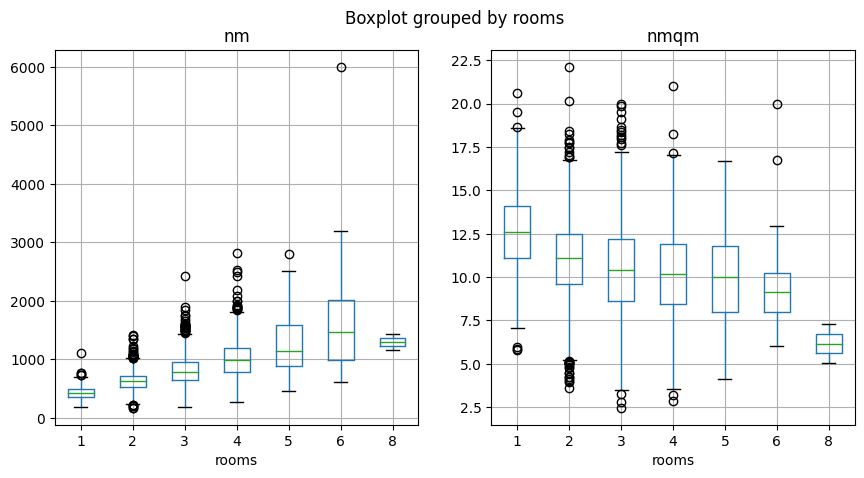

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
mietspiegel2015.boxplot(by="rooms", column="nm", ax=ax[0])
mietspiegel2015.boxplot(by="rooms", column="nmqm", ax=ax[1])
plt.show()

Für Wohnungen mit mehreren Räumen haben wir eine höhere Nettomiete (`nm`). Soweit zu erwarten.
Für Wohnungen mit weniger (<5) Räumen existieren deutlich mehr Ausreißer als für größere Wohnungen.

Jedoch sinkt die Nettomiete pro Quadratmeter für Wohnungen mit mehreren Räumen leicht.

Da es vergleichsweise wenige Wohnungen mit 8 Räumen gibt, ist hier der Boxplot unspektakulärer.

(6) Erkunden Sie nun etwaige Zusammenhänge zwischen den Variablen Nettomiete (nm), Nettomiete/Quadratmeter (nmqm), Wohnfläche (wfl) und Anzahl der Räume (rooms), indem Sie einen [Scatter-Matrix-Plot](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.plotting.scatter_matrix.html) erstellen.

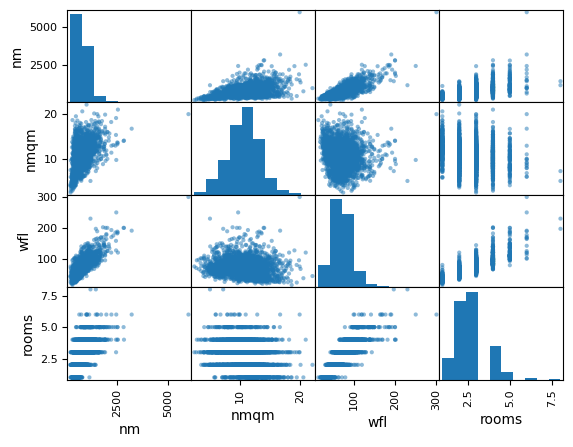

In [16]:
mietspiegel2015_nm_nmqm_wfl_rooms = mietspiegel2015[["nm", "nmqm", "wfl", "rooms"]]

pd.plotting.scatter_matrix(mietspiegel2015_nm_nmqm_wfl_rooms)
plt.show()

(7) Interpretieren Sie den Ihren Plot aus Schritt 6: Sehen Sie Zusammenhänge zwischen einzelnen Variablen? (1-3 Sätze)

- `nm`
    - `nmqm`: für sehr kleine nmqm gibt es keine große nm, da es sich hier vermutlich um sehr kleine Wohnungen handelt.
    - `wfl`: Es ist eine (vergleichsweise) positive Korrelation zu erkennen
    - `rooms`: Wie auch bei wfl ist eine positive Korrelation zu erkennen; diese ist jedoch deutlich schwächer, als bei wfl
- `nmqm`
    - `wfl`: Es ist keine Korrelation zu erkennen
    - `rooms`: Es ist keine Korrelation zu erkennen
- `wfl`
    - `rooms`: es ist eine (vergleichsweise) positive Korrelation zu erkennen

*Da die Matrix symmetrisch ist, wurden die Gegenpaare ($a,b \rightarrow b,a$) weggelassen*

(8) Berechnen Sie Pearsons Korrelationskoeffizienten für alle Paare von Variablen aus Schritt (6). Schätzen Sie ein, welche Variablen miteinander schwach, mittel oder stark korreliert sind. Interpretieren Sie Ihre Ergebnisse (1-3 Sätze). Achten Sie dabei unter anderem auf Ihren Befund zwischen Zimmerzahl und Nettomiete/Quadratmeter sowie Nettomiete und Wohnfläche.

In [17]:
mietspiegel2015_nm_nmqm_wfl_rooms.corr()

,nm,nmqm,wfl,rooms
nm,1.000000,0.462052,0.783243,0.587658
nmqm,0.462052,1.000000,-0.136143,-0.216358
wfl,0.783243,-0.136143,1.000000,0.838881
rooms,0.587658,-0.216358,0.838881,1.000000


Wie bereits vermutet, sind die einzigen als solche zu beachtenden Korrelationen zwischen `nm` und `wfl`, sowie `wfl` und `rooms`.

Zwischen Zimmerzahl und Nettomiete pro Quadratmeter existiert laut unserer Faustformel keine bzw. nur eine sehr schwache Korrelation.
Nettomiete und Wohnfläche sind bereits oben als mittlere bis starke Korrelation aufgelistet. 

(9) Berechnen Sie Spearmans Korrelationskoeffizient für alle Paare von Variablen aus Schritt (6). Vergleichen Sie die Werte, die Sie erhalten, mit den Werten von Pearsons Korrelationskoeffizienten aus Schritt (8). Für welches Feature-Paar sehen Sie in beiden Koeffizienten die größten Unterschiede? Wie interpretieren Sie diesen Unterschied?

* Wenn Sie wünschen, finden Sie hier einen ROT13-kodierten Hinweis: Fpuyntra Fvr va qre Ibeyrfhat anpu, jrypur Neg iba Mhfnzzraunat Crnefbaf Xbeeryngvbafxbrssvmvrag haq jrypur Neg iba Mhfnzzraunat Fcrneznaf Xbeeryngvbafxbrssvmvrag punenxgrevfvrera.

In [18]:
mietspiegel2015_nm_nmqm_wfl_rooms.corr("spearman")

,nm,nmqm,wfl,rooms
nm,1.000000,0.437574,0.750244,0.607100
nmqm,0.437574,1.000000,-0.177474,-0.224491
wfl,0.750244,-0.177474,1.000000,0.859069
rooms,0.607100,-0.224491,0.859069,1.000000


In [19]:
(mietspiegel2015_nm_nmqm_wfl_rooms.corr("spearman") - mietspiegel2015_nm_nmqm_wfl_rooms.corr()).abs()

,nm,nmqm,wfl,rooms
nm,0.000000,0.024477,0.032999,0.019442
nmqm,0.024477,0.000000,0.041331,0.008133
wfl,0.032999,0.041331,0.000000,0.020188
rooms,0.019442,0.008133,0.020188,0.000000


Die größten Unterschiede sehen wir bei `wfl` zu `nmqm` (0.041331).

Den Unterschied könnten wir uns erklären, wenn Teile der Daten weiter "auseinander liegen" als andere und diese Gruppen mehrere voneinander trennbare Cluster ergeben, die nach Abstand sortiert gelistet sind.
Sprich, der Unterschied der Daten ist gravierender, als die Reihenfolge.
Z. B. rg[-50, -10, 0, 1, 5] -> [0, 1, 2, 3, 4]

### 4.4 Pearsons Korrelationskoeffizient und Invarianz

Betrachten Sie die beiden Merkmale $X$ und $Y$ sowie ihre linearen Transformationen

$$\tilde{X} = a_X X + b_X, \quad a_X\neq 0$$

und

$$\tilde{Y} = a_Y Y + b_Y, \quad a_Y\neq 0$$


**Ihre Aufgaben**

(1) Schlagen Sie in der Vorlesung die Definition von Pearsons Korrelationskoeffizienten nach.

$$r = r_{xy} = \frac{\sum_{i=1}^n ((x_i - \overline{x}) \cdot (y_i - \overline{y}))}{\sqrt{\sum_{i=1}^n (x_i - \overline{x})^2} \cdot \sqrt{\sum_{i=1}^n (y_i - \overline{y})^2}} = \frac{\tilde{s}_{XY}}{\tilde{s}_X \cdot \tilde{s}_Y}$$

mit

$$\tilde{s}_X = \sqrt{\frac{1}{n-1} \cdot \sum_{i=1}^n (x_i - \overline{x})^2}, \tilde{s}_Y = \sqrt{\frac{1}{n-1} \cdot \sum_{i=1}^n (y_i - \overline{y})^2}, \tilde{s}_{XY} = \frac{1}{n-1} \cdot \sum_{i=1}^n (x_i - \overline{x}) \cdot (y_i - \overline{y})$$

(2) Zeigen Sie, dass für Pearsons Korrelationskoeffizient $r_{XY}$ gilt:

$$ |r_{\tilde{X}\tilde{Y}}| = |r_{XY}|$$

Diese Invarianz unter linearen Transformationen wird auch *Maßstabsunabhängigkeit* genannt.

$$|r_{\tilde{X}\tilde{Y}}| \stackrel{?}{=} |r_{XY}|$$

Seien

$
\begin{align}
\tilde{s}_{\tilde{X}} & = \sqrt{\frac{1}{n-1} \cdot \sum_{i=1}^n (\tilde{x}_i - \overline{\tilde{x}})^2} \\
& = \sqrt{\frac{1}{n-1} \cdot \sum_{i=1}^n (a_X \cdot x_i + b_X - \frac{1}{n} \cdot \sum_{j=0}^n (a_X \cdot x_j + b_X))^2} \\
& = \sqrt{\frac{1}{n-1} \cdot \sum_{i=1}^n (a_X \cdot x_i + b_X - \frac{1}{n} \cdot (a_X \cdot \sum_{j=0}^n (x_j) + n \cdot b_X))^2} \\
& = \sqrt{\frac{1}{n-1} \cdot \sum_{i=1}^n (a_X \cdot x_i + b_X - \frac{1}{n} \cdot (a_X \cdot \sum_{j=0}^n (x_j)) - \frac{\sout{n}}{\sout{n}} \cdot b_X)^2} \\
& = \sqrt{\frac{1}{n-1} \cdot \sum_{i=1}^n (a_X \cdot x_i + \sout{b_X} - \frac{1}{n} \cdot (a_X \cdot \sum_{j=0}^n (x_j)) - \sout{b_X})^2} \\
& = \sqrt{\frac{1}{n-1} \cdot \sum_{i=1}^n (a_X \cdot x_i - a_X \cdot \frac{1}{n} \cdot \sum_{j=0}^n (x_j))^2} \\
& = \sqrt{\frac{1}{n-1} \cdot \sum_{i=1}^n (a_X \cdot x_i - a_X \cdot \overline{x})^2} \\
& = \sqrt{\frac{1}{n-1} \cdot \sum_{i=1}^n (a_X \cdot (x_i - \overline{x}))^2} \\
& = \sqrt{a_X^2 \cdot \frac{1}{n-1} \cdot \sum_{i=1}^n (x_i - \overline{x})^2} \\
& = |a_X| \cdot \sqrt{\frac{1}{n-1} \cdot \sum_{i=1}^n (x_i - \overline{x})^2} \\
& = |a_X| \cdot \tilde{s}_X, \\[25pt]
\tilde{s}_{\tilde{Y}} & = \sqrt{\frac{1}{n-1} \cdot \sum_{i=1}^n (\tilde{y}_i - \overline{\tilde{y}})^2} \\
& = a_Y \cdot \tilde{s}_Y, \\[25pt]
\tilde{s}_{\tilde{X}\tilde{Y}} & = \frac{1}{n-1} \cdot \sum_{i=1}^n (\tilde{x}_i - \overline{\tilde{x}}) \cdot (\tilde{y}_i - \overline{\tilde{y}}) \\
& = \frac{1}{n-1} \cdot \sum_{i=1}^n (a_X \cdot (x_i - \overline{x})) \cdot (a_Y \cdot (y_i - \overline{y})) \\
& = \frac{1}{n-1} \cdot \sum_{i=1}^n a_X \cdot a_Y \cdot (x_i - \overline{x}) \cdot (y_i - \overline{y}) \\
& = a_X \cdot a_Y \cdot \frac{1}{n-1} \cdot \sum_{i=1}^n (x_i - \overline{x}) \cdot (y_i - \overline{y}) \\
& = a_X \cdot a_Y \cdot \tilde{s}_{XY} \\
\end{align}
$

So gilt

$
\begin{align}
|r_{\tilde{X}\tilde{Y}}| & = |\frac{\tilde{s}_{\tilde{X}\tilde{Y}}}{\tilde{s}_{\tilde{X}} \cdot \tilde{s}_{\tilde{Y}}}| \\
& = |\frac{\sout{a_X} \cdot \sout{a_Y} \cdot \tilde{s}_{XY}}{|\sout{a_X}| \cdot \tilde{s}_X \cdot |\sout{a_Y}| \cdot \tilde{s}_Y}| \\
& = |\frac{1}{\text{sign}(a_X) \cdot \text{sign}(a_Y)} \cdot \frac{\tilde{s}_{XY}}{\tilde{s}_X \cdot \tilde{s}_Y}| \\
& = |\text{sign}(a_X \cdot a_Y) \cdot \frac{\tilde{s}_{XY}}{\tilde{s}_X \cdot \tilde{s}_Y}| \\
& = \sout{|\text{sign}(a_X \cdot a_Y)|} \cdot |\frac{\tilde{s}_{XY}}{\tilde{s}_X \cdot \tilde{s}_Y}| \\
& = |r_{XY}|
\end{align}
$

Da $a_X \neq 0 \land a_Y \neq 0$ und somit $a_X \cdot a_Y \neq 0$ und $\text{sign}(a_X \cdot a_Y) \in \{-1, 1\} \ \forall a_X, a_Y$

Oder alternativ:

Mit der Definition des Korrelationskoeffizienten gilt unmittelbar $\text{Korr}(aX + b, Y) = \text{sgn}(a) \cdot \text{Korr}(X, Y)$ [1], da der Korrelationskoeffizienten auf der Kovarianz und auf der Wurzel der Varianz aufbaut<sup>1</sup> [2].
Die Kovarianz ist eine positiv semidefinite symmetrische Bilinearform auf dem Vektorraum der quadratisch integrierbaren Zufallsvariablen [3].
Somit haben additive Konstanten keine Auswirkung auf die Kovarianz; bei multiplikativen Konstanten wird die Kovarianz um die jeweiligen Faktoren skaliert ($\text{Cov}(aX + b, cY + d) = ac \text{Cov}(X, Y)$ [3]).
Da bei der Varianz additive Konstanten keine Auswirkung auf die Streuung haben, sowie durch die Linearität des Erwartungswerts multiplikative Konstanten ($a$) die Varianz um $a^2$ skalieren ($\text{Var}(aX + b) = a^2 \text{Var}(X)$) [4], kürzen sich die Skalare des Bruches gegenseitig weg.
Somit gilt offensichtlich $|r_{\tilde{X}\tilde{Y}}| = |r_{XY}|$.

$^1 \text{Korr}(X, Y) = \frac{\text{Cov}(X, Y)}{\sqrt(\text{Var}(X)) \sqrt(\text{Var}(Y))}$

[1] [Korrelationskoeffizient#Eigenschaften](https://de.wikipedia.org/wiki/Korrelationskoeffizient#Eigenschaften) <br />
[2] [Korrelationskoeffizient#Definition](https://de.wikipedia.org/wiki/Korrelationskoeffizient#Definition) <br />
[3] [Kovarianz_(Stochastik)#Linearit](https://de.wikipedia.org/wiki/Kovarianz_(Stochastik)#Linearit%C3%A4t,_Symmetrie_und_Definitheit) <br />
[4] [Varianz_(Stochastik)#Lineare_Transformation](https://de.wikipedia.org/wiki/Varianz_(Stochastik)#Lineare_Transformation)